In [ ]:
# Name: DVN Surya Kiran
# Roll No: CH.SC.U4CSE24116
# Lab 12 Exercise 1 - Random Forest Fruit Basket Majority Voting

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sn

In [ ]:
data = {
    'Weight':     [150, 120, 180, 200, 130, 160, 110, 190, 140, 170,
                   145, 125, 185, 195, 135, 155, 115, 188, 142, 168],
    'Diameter':   [7.5, 6.0, 8.0, 9.0, 6.5, 7.8, 5.8, 8.5, 7.0, 8.2,
                   7.3, 6.2, 8.1, 8.8, 6.7, 7.6, 5.9, 8.4, 7.1, 8.0],
    'Sweetness':  [8, 5, 7, 6, 4, 8, 5, 7, 8, 6,
                   8, 5, 7, 6, 4, 8, 5, 7, 8, 6],
    'Texture':    [1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
                   1, 0, 1, 0, 0, 1, 0, 1, 1, 0],
    'Fruit':      ['Apple','Banana','Apple','Banana','Banana','Apple','Banana','Apple','Apple','Banana',
                   'Apple','Banana','Apple','Banana','Banana','Apple','Banana','Apple','Apple','Banana']
}
df = pd.DataFrame(data)
print(df)

    Weight  Diameter  Sweetness  Texture   Fruit
0      150       7.5          8        1   Apple
1      120       6.0          5        0  Banana
2      180       8.0          7        1   Apple
3      200       9.0          6        0  Banana
4      130       6.5          4        0  Banana
5      160       7.8          8        1   Apple
6      110       5.8          5        0  Banana
7      190       8.5          7        1   Apple
8      140       7.0          8        1   Apple
9      170       8.2          6        0  Banana
10     145       7.3          8        1   Apple
11     125       6.2          5        0  Banana
12     185       8.1          7        1   Apple
13     195       8.8          6        0  Banana
14     135       6.7          4        0  Banana
15     155       7.6          8        1   Apple
16     115       5.9          5        0  Banana
17     188       8.4          7        1   Apple
18     142       7.1          8        1   Apple
19     168       8.0

In [ ]:
print(df.isnull().sum())
print(df.shape)
print("\nFruit distribution:")
print(df['Fruit'].value_counts())

Weight       0
Diameter     0
Sweetness    0
Texture      0
Fruit        0
dtype: int64
(20, 5)

Fruit distribution:
Fruit
Apple     10
Banana    10
Name: count, dtype: int64


In [ ]:
df['Fruit_Encoded'] = df['Fruit'].map({'Apple': 0, 'Banana': 1})
x = df[['Weight', 'Diameter', 'Sweetness', 'Texture']]
y = df['Fruit_Encoded']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)
print(x_train.shape, x_test.shape)

(14, 4) (6, 4)


In [ ]:
sc = StandardScaler()
x_train_sc = sc.fit_transform(x_train)
x_test_sc = sc.transform(x_test)

In [ ]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
model.fit(x_train_sc, y_train)
y_pred = model.predict(x_test_sc)
print("Predicted:", ['Apple' if p==0 else 'Banana' for p in y_pred])
print("Actual:   ", ['Apple' if p==0 else 'Banana' for p in y_test.values])

Predicted: ['Apple', 'Apple', 'Apple', 'Banana', 'Apple', 'Apple']
Actual:    ['Apple', 'Apple', 'Apple', 'Banana', 'Apple', 'Apple']


In [ ]:
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_mat)
print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Accuracy %:", int(metrics.accuracy_score(y_test, y_pred)*100), '%')
print("\nClassification Report:\n", metrics.classification_report(y_test, y_pred,
      target_names=['Apple', 'Banana']))

Confusion Matrix:
 [[5 0]
 [0 1]]
Accuracy: 1.0
Accuracy %: 100 %

Classification Report:
               precision    recall  f1-score   support

       Apple       1.00      1.00      1.00         5
      Banana       1.00      1.00      1.00         1

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



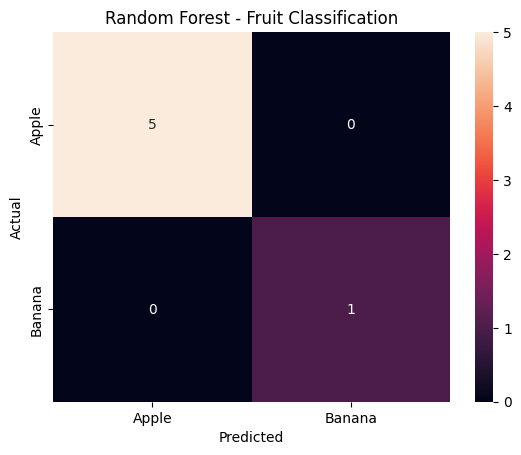

In [ ]:
sn.heatmap(conf_mat, annot=True, fmt='d',
           xticklabels=['Apple','Banana'],
           yticklabels=['Apple','Banana'])
plt.title('Random Forest - Fruit Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

     Feature  Importance
3    Texture    0.680352
2  Sweetness    0.200000
0     Weight    0.100000
1   Diameter    0.019648


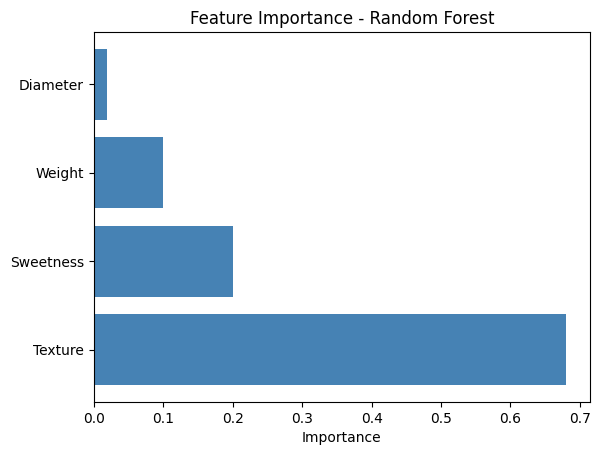

In [ ]:
feature_imp = pd.DataFrame({
    'Feature': x.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)
print(feature_imp)
plt.barh(feature_imp['Feature'], feature_imp['Importance'], color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()

In [ ]:
votes = {}
for i, tree in enumerate(model.estimators_):
    pred = tree.predict(x_test_sc)
    for j, p in enumerate(pred):
        key = f"Sample_{j+1}"
        if key not in votes:
            votes[key] = {'Apple': 0, 'Banana': 0}
        label = 'Apple' if p == 0 else 'Banana'
        votes[key][label] += 1

print("Majority Voting Results (10 trees):")
print("-" * 40)
for sample, vote in votes.items():
    winner = max(vote, key=vote.get)
    print(f"{sample}: Apple={vote['Apple']} | Banana={vote['Banana']} → Winner: {winner}")

Majority Voting Results (10 trees):
----------------------------------------
Sample_1: Apple=10 | Banana=0 → Winner: Apple
Sample_2: Apple=10 | Banana=0 → Winner: Apple
Sample_3: Apple=10 | Banana=0 → Winner: Apple
Sample_4: Apple=0 | Banana=10 → Winner: Banana
Sample_5: Apple=9 | Banana=1 → Winner: Apple
Sample_6: Apple=10 | Banana=0 → Winner: Apple


In [ ]:
print("\nConclusion:")
print("Based on majority voting across all decision trees:")
print("Apple (Class-A) receives more votes → Apple is taken more often")
print("This matches the figure in the book where Class-A (Apple) wins by majority.")
print("\nRandom Forest combines multiple trees → more accurate than single Decision Tree")


Conclusion:
Based on majority voting across all decision trees:
Apple (Class-A) receives more votes → Apple is taken more often
This matches the figure in the book where Class-A (Apple) wins by majority.

Random Forest combines multiple trees → more accurate than single Decision Tree
